In [1]:
#imports
from plantcv import plantcv as pcv
import cv2
import numpy as np
from skimage import morphology
from calculate_rois import auto_roi

In [2]:
#read in image
image_path = "plant_image.jpg"

img, path, filename = pcv.readimage(filename=image_path)

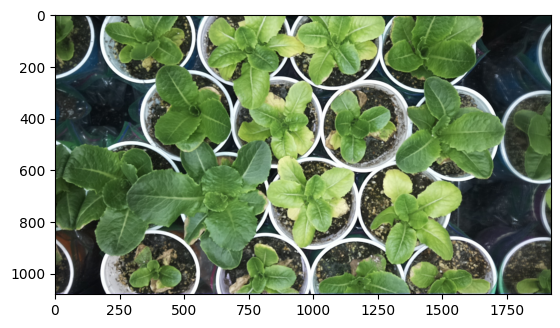

In [3]:
pcv.plot_image(img)

In [4]:
#mask the image with an example mask. Filter out small areas
# Convert to HSV and LAB color spaces
hsv_image = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
lab_image = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

# Define HSV range for filtering using OpenCV
# OpenCV uses 0-180 for Hue, so the values are halved
hsv_min = np.array([int(28/2), int(20/100*255), int(20/100*255)])
hsv_max = np.array([int(144/2), 255, 255])
hsv_mask = cv2.inRange(hsv_image, hsv_min, hsv_max)

# Define LAB range for filtering using OpenCV
# OpenCV uses 0-255 for L, a*, and b*
# Note: 'a' and 'b' ranges need to be shifted from [-128, 127] to [0, 255]
# L is scaled from [0, 100] in LAB to [0, 255] in OpenCV
lab_lower = np.array([int(10/100*255), 0, 132])
lab_upper = np.array([int(90/100*255), 124, 255])
lab_mask = cv2.inRange(lab_image, lab_lower, lab_upper)

# Combine the masks (logical AND) and apply to the original image
combined_mask = cv2.bitwise_and(hsv_mask, lab_mask)

In [5]:
# Define a kernel for morphological operation
kernel = np.ones((25, 25), np.uint8)

# Apply morphological opening
opened_mask = cv2.morphologyEx(combined_mask, cv2.MORPH_OPEN, kernel)

In [6]:
#remove small holes in the image so object detection won't be as bad
# Remove small objects
cleaned_mask = pcv.fill(opened_mask, size=1000)

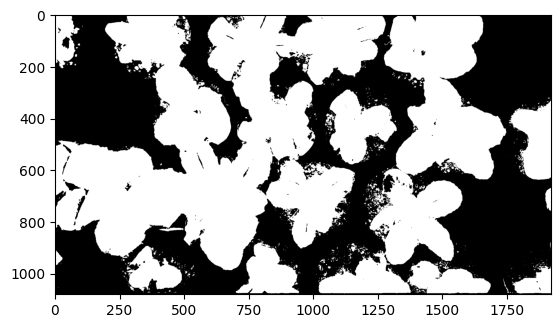

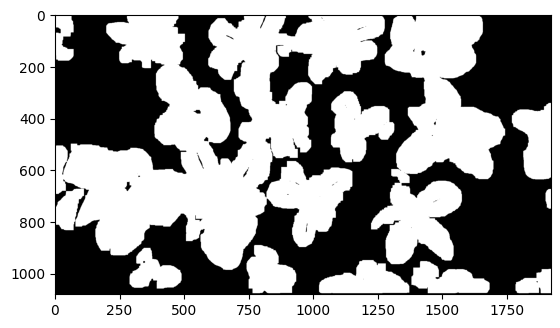

In [7]:
pcv.plot_image(combined_mask)
pcv.plot_image(cleaned_mask)

In [8]:
#generate automatic labels from denoised mask
#create labels for masks that may have plants, count number of objects
labeled_image, number_of_plants = pcv.create_labels(mask=cleaned_mask)

12


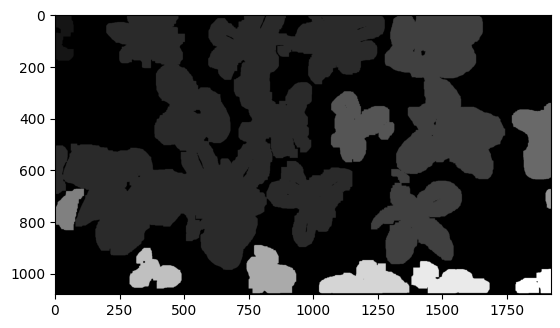

In [9]:
print(number_of_plants)
pcv.plot_image(labeled_image)

In [10]:
#get the centers and optimal radius size
centers, optimal_radius_size = auto_roi(labeled_image)

In [11]:
print(centers)
print(optimal_radius_size)

[(35, 89), (636, 493), (1479, 482), (1188, 434), (1842, 490), (55, 753), (1907, 712), (835, 983), (388, 980), (1194, 1012), (1527, 1014), (1849, 1029)]
13


In [12]:
#now that this is calculated, use pcv.roi.multi to automatically generate the rois
rois = pcv.roi.multi(img=img, coord=centers, radius=optimal_radius_size)

In [13]:
rois